In [1]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np
import matplotlib.pyplot as plt
LOG.propagate = False

In [2]:
# Get ArtemisBLEController object
ble = get_ble_controller()
# Connect to the Artemis Device
ble.connect()

2025-03-12 15:42:41,617 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:e0:ec:f0:72:02
2025-03-12 15:42:45,839 | INFO     |: Connected to c0:e0:ec:f0:72:02


C:\CornellCourse\ECE5160\ble_robot_1.2\ble_python\base_ble.py:104: FutureWarning: This method will be removed future version, pass the callback to the BleakClient constructor instead.
  self.client.set_disconnected_callback(self.disconnect_handler)


In [3]:
orient_time = []
orient_yaw = []
orient_error = []
orient_output = []
orient_motor = []
notification_count = 0
# Define a notification handler to parse orientation data
def orientation_notification_handler(sender: int, data: bytearray):
    """
    Expected message format for orientation data:
      "T:<time>|Y:<yaw>|E:<error>|U:<output>|M:<motorCmd>"
    where each field is a float except time might be an int (in ms).
    Example: "T:1012|Y:-23.5|E:20.0|U:15.7|M:16"
    """
    global notification_count
    try:
        message = data.decode("utf-8").strip()
        # Check if it starts with "T:" to be sure it's orientation data
        if message.startswith("T:"):
            parts = message.split("|")
            if len(parts) < 5:
                print(f"Incomplete orientation data: {message}")
                return
            # Parse each field
            t = float(parts[0].split(":")[1])  # T:xxx
            y = float(parts[1].split(":")[1])  # Y:xxx
            e = float(parts[2].split(":")[1])  # E:xxx
            u = float(parts[3].split(":")[1])  # U:xxx
            m = float(parts[4].split(":")[1])  # M:xxx
            # Store in global lists
            orient_time.append(t)
            orient_yaw.append(y)
            orient_error.append(e)
            orient_output.append(u)
            orient_motor.append(m)
            notification_count += 1
            print(f"Orientation Data #{notification_count}: {message}")
        else:
            # Could be an ACK or another message
            print(f"Ack or other notification: {message}")
    except Exception as ex:
        print("Error parsing orientation notification:", ex)

In [4]:
ble.start_notify(ble.uuid['RX_STRING'], orientation_notification_handler)


In [14]:
myKp = 5
myKi = 0.005
myKd = 10
mySetpoint = 0.0

# Format: "Kp|Ki|Kd|Setpoint"
ble.send_command(CMD.SET_ORIENTATION_GAINS,
                 f"{myKp}|{myKi}|{myKd}|{mySetpoint}")

Ack or other notification: OK: orientKp=5.000, orientKi=0.005, orientKd=10.000, setpoint=0.000


In [15]:
orient_time = []
orient_yaw = []
orient_error = []
orient_output = []
orient_motor = []

notification_count = 0

In [16]:
test_duration_ms = 10000
ble.send_command(CMD.START_ORIENTATION_CONTROL, str(test_duration_ms))


Ack or other notification: Orientation PID for 10000 ms


In [17]:
ble.send_command(CMD.GET_ORIENTATION_DATA, "")

Orientation Data #1: T:1544459|Y:-18.633|E:18.633|U:94.666|M:94
Orientation Data #2: T:1544462|Y:-18.633|E:18.633|U:94.666|M:94
Orientation Data #3: T:1544478|Y:-18.633|E:18.633|U:94.666|M:94
Orientation Data #4: T:1544489|Y:-18.633|E:18.633|U:94.666|M:94
Orientation Data #5: T:1544506|Y:-18.633|E:18.633|U:94.666|M:94
Orientation Data #6: T:1544517|Y:-18.640|E:18.640|U:94.700|M:94
Orientation Data #7: T:1544528|Y:-18.645|E:18.645|U:94.728|M:94
Orientation Data #8: T:1544539|Y:-18.645|E:18.645|U:94.728|M:94
Orientation Data #9: T:1544549|Y:-18.645|E:18.645|U:94.728|M:94
Orientation Data #10: T:1544560|Y:-18.645|E:18.645|U:94.728|M:94
Orientation Data #11: T:1544576|Y:-18.645|E:18.645|U:94.728|M:94
Orientation Data #12: T:1544589|Y:-18.645|E:18.645|U:94.728|M:94
Orientation Data #13: T:1544599|Y:-18.645|E:18.645|U:94.728|M:94
Orientation Data #14: T:1544610|Y:-18.645|E:18.645|U:94.728|M:94
Orientation Data #15: T:1544621|Y:-18.645|E:18.645|U:94.728|M:94
Orientation Data #16: T:1544627|Y:

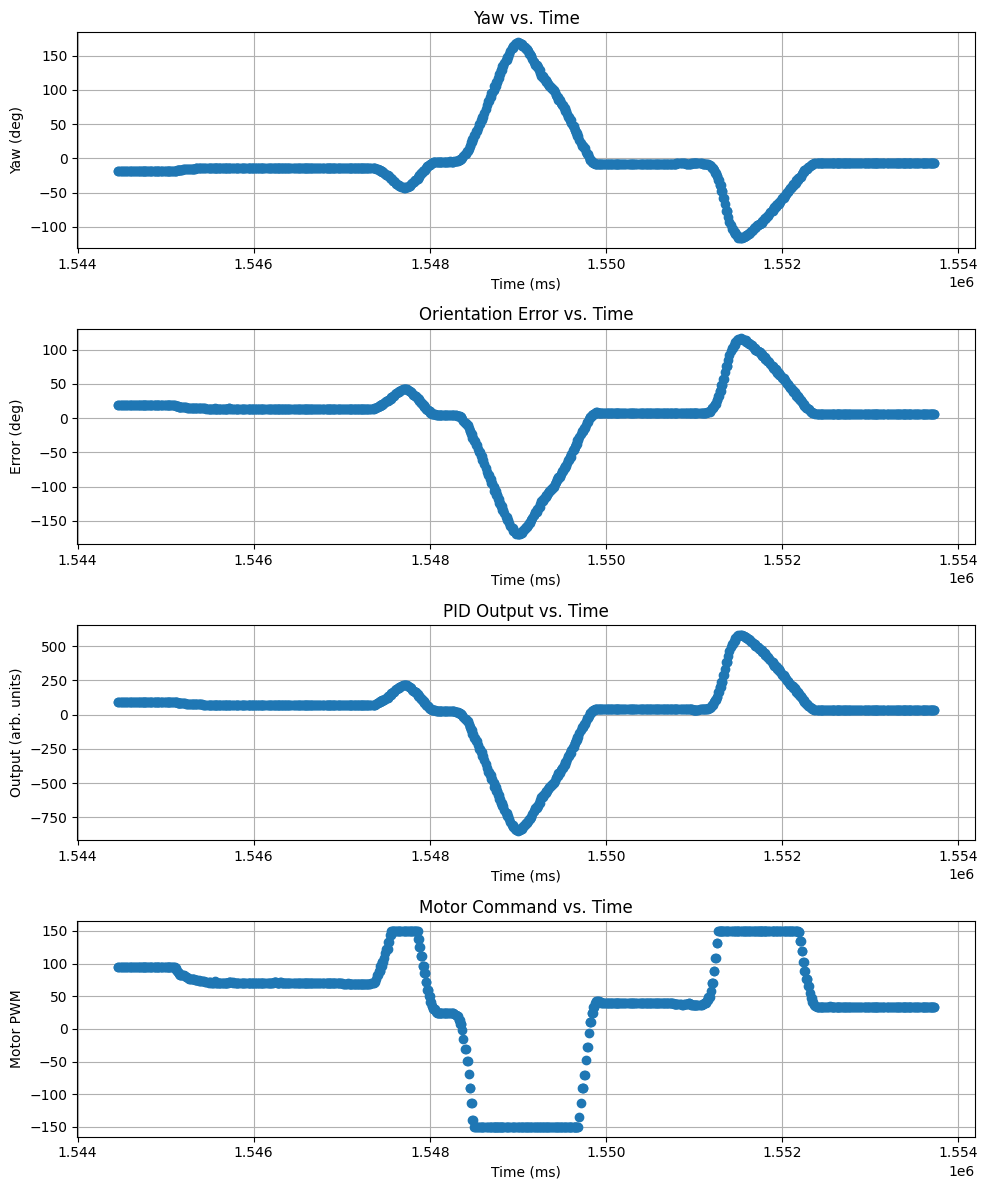

In [18]:
plt.figure(figsize=(10, 12))

plt.subplot(4, 1, 1)
plt.plot(orient_time, orient_yaw, 'o')
plt.title("Yaw vs. Time")
plt.xlabel("Time (ms)")
plt.ylabel("Yaw (deg)")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(orient_time, orient_error, 'o')
plt.title("Orientation Error vs. Time")
plt.xlabel("Time (ms)")
plt.ylabel("Error (deg)")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(orient_time, orient_output, 'o')
plt.title("PID Output vs. Time")
plt.xlabel("Time (ms)")
plt.ylabel("Output (arb. units)")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(orient_time, orient_motor, 'o')
plt.title("Motor Command vs. Time")
plt.xlabel("Time (ms)")
plt.ylabel("Motor PWM")
plt.grid(True)

plt.tight_layout()
plt.show()
